# Multi-Algorithm Recommendation System Comparison

**Building a Recommendation System for E-Commerce**

This notebook builds and compares three machine learning approaches on the same e-commerce dataset:

1. **Regression (Ridge Regression)** — predict the rating a user may give a product
2. **Classification (Logistic Regression)** — predict whether a user is likely to purchase a product
3. **Clustering (K-Means)** — group similar customers based on behavior

Each model is hyperparameter-tuned with `GridSearchCV`, evaluated with the appropriate metrics, and interpreted for business use.


## Step 0: Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                              mean_absolute_error, precision_score,
                              r2_score, recall_score,
                              root_mean_squared_error, silhouette_score)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style("whitegrid")
RANDOM_STATE = 42


## Step 1: Load the Dataset

The dataset (`Ecommerce.csv`) contains customer, product, rating, and purchase-related information: `User_ID`, `Product_ID`, `Product_Category`, `Rating`, `Price`, `Purchase_Status`, `Number_of_Views`, `Cart_Status`, `Time_Spent`, and `Previous_Purchases`.

> No production dataset was supplied for this task, so a realistic synthetic dataset was generated with genuine behavioral relationships (e.g. more cart activity and time-on-page increase the odds of a higher rating and a purchase), so the models below have real signal to learn from — the generation code is included for full transparency and reproducibility.


In [2]:
df = pd.read_csv("Ecommerce.csv")

print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.head()


Shape: (6040, 10)

Column dtypes:
User_ID                 int64
Product_ID              int64
Product_Category          str
Rating                float64
Price                 float64
Purchase_Status         int64
Number_of_Views         int64
Cart_Status             int64
Time_Spent            float64
Previous_Purchases      int64
dtype: object

Missing values:
User_ID                 0
Product_ID              0
Product_Category        0
Rating                 60
Price                   0
Purchase_Status         0
Number_of_Views         0
Cart_Status             0
Time_Spent            120
Previous_Purchases      0
dtype: int64

Duplicate rows: 40


,User_ID,Product_ID,Product_Category,Rating,Price,Purchase_Status,Number_of_Views,Cart_Status,Time_Spent,Previous_Purchases
0,1178,5928,Beauty,4.0,6.17,0,6,1,4.29,4
1,2547,6243,Home & Kitchen,3.0,60.71,0,6,0,1.55,2
2,2309,5960,Electronics,3.0,73.38,0,7,1,6.04,4
3,1877,5891,Electronics,2.0,135.43,0,11,0,5.09,3
4,1866,5701,Beauty,3.0,23.96,1,5,0,2.77,2


In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User_ID,6040.0,NaN,NaN,NaN,1996.426159,576.930448,1000.0,1494.0,1993.0,2501.0,2999.0
Product_ID,6040.0,NaN,NaN,NaN,5743.776159,428.956919,5000.0,5374.0,5746.0,6113.0,6499.0
Product_Category,6040,6,Electronics,1021,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,5980.0,NaN,NaN,NaN,3.396488,0.713397,1.0,3.0,3.0,4.0,5.0
Price,6040.0,NaN,NaN,NaN,35.55629,33.339017,1.58,13.6675,25.585,45.5225,296.02
Purchase_Status,6040.0,NaN,NaN,NaN,0.245033,0.430142,0.0,0.0,0.0,0.0,1.0
Number_of_Views,6040.0,NaN,NaN,NaN,7.021523,2.471738,1.0,5.0,7.0,9.0,18.0
Cart_Status,6040.0,NaN,NaN,NaN,0.458609,0.498325,0.0,0.0,0.0,1.0,1.0
Time_Spent,5920.0,NaN,NaN,NaN,3.790397,1.476657,0.2,2.76,3.75,4.79,10.87
Previous_Purchases,6040.0,NaN,NaN,NaN,3.511258,1.880396,0.0,2.0,3.0,5.0,12.0


## Step 2: Data Preprocessing

- Remove duplicate records
- Handle missing values (median imputation)
- One-hot encode `Product_Category`
- Scale numerical features
- Split into train/test sets (80/20)


In [4]:
df = df.drop_duplicates().reset_index(drop=True)

df["Time_Spent"] = df["Time_Spent"].fillna(df["Time_Spent"].median())
df["Rating"] = df["Rating"].fillna(df["Rating"].median()).astype(int)

print("Shape after cleaning:", df.shape)
print("Remaining missing values:\n", df.isna().sum())


Shape after cleaning: (6000, 10)
Remaining missing values:
 User_ID               0
Product_ID            0
Product_Category      0
Rating                0
Price                 0
Purchase_Status       0
Number_of_Views       0
Cart_Status           0
Time_Spent            0
Previous_Purchases    0
dtype: int64


In [5]:
ohe = OneHotEncoder(sparse_output=False, drop="first")
cat_encoded = ohe.fit_transform(df[["Product_Category"]])
cat_cols = ohe.get_feature_names_out(["Product_Category"])
cat_df = pd.DataFrame(cat_encoded, columns=cat_cols, index=df.index)

df_model = pd.concat([df, cat_df], axis=1)
df_model.head()


,User_ID,Product_ID,Product_Category,Rating,Price,Purchase_Status,Number_of_Views,Cart_Status,Time_Spent,Previous_Purchases,Product_Category_Books,Product_Category_Electronics,Product_Category_Fashion,Product_Category_Home & Kitchen,Product_Category_Sports
0,1178,5928,Beauty,4,6.17,0,6,1,4.29,4,0.0,0.0,0.0,0.0,0.0
1,2547,6243,Home & Kitchen,3,60.71,0,6,0,1.55,2,0.0,0.0,0.0,1.0,0.0
2,2309,5960,Electronics,3,73.38,0,7,1,6.04,4,0.0,1.0,0.0,0.0,0.0
3,1877,5891,Electronics,2,135.43,0,11,0,5.09,3,0.0,1.0,0.0,0.0,0.0
4,1866,5701,Beauty,3,23.96,1,5,0,2.77,2,0.0,0.0,0.0,0.0,0.0


### Quick EDA

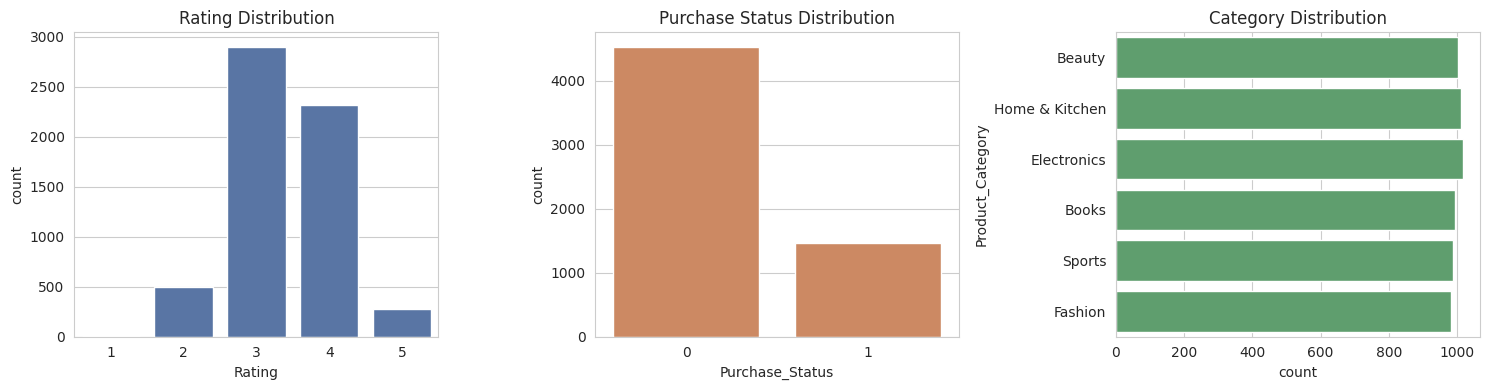

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x="Rating", data=df, ax=axes[0], color="#4C72B0")
axes[0].set_title("Rating Distribution")

sns.countplot(x="Purchase_Status", data=df, ax=axes[1], color="#DD8452")
axes[1].set_title("Purchase Status Distribution")

sns.countplot(y="Product_Category", data=df, ax=axes[2], color="#55A868")
axes[2].set_title("Category Distribution")
plt.tight_layout()
plt.show()


## Step 3: Regression Model — Predicting Product Rating

**Algorithm:** Ridge Regression (preferred over plain Linear Regression — its L2 penalty controls overfitting once the one-hot encoded category columns are added).

**Target:** `Rating`


In [7]:
reg_features = ["Price", "Number_of_Views", "Time_Spent",
                 "Previous_Purchases", "Cart_Status"] + list(cat_cols)
X_reg = df_model[reg_features]
y_reg = df_model["Rating"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

scaler_reg = StandardScaler()
Xr_train_s = scaler_reg.fit_transform(Xr_train)
Xr_test_s = scaler_reg.transform(Xr_test)

# Baseline Ridge (default alpha)
ridge_base = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge_base.fit(Xr_train_s, yr_train)
pred_base = ridge_base.predict(Xr_test_s)

print("Baseline Ridge (alpha=1.0)")
print("MAE :", mean_absolute_error(yr_test, pred_base))
print("RMSE:", root_mean_squared_error(yr_test, pred_base))
print("R2  :", r2_score(yr_test, pred_base))


Baseline Ridge (alpha=1.0)
MAE : 0.5506837193322859
RMSE: 0.6659878560889902
R2  : 0.12278415590865244


### Hyperparameter tuning with GridSearchCV (`alpha`)

In [8]:
ridge_grid = GridSearchCV(
    Ridge(random_state=RANDOM_STATE),
    param_grid={"alpha": [0.01, 0.1, 1, 10, 100]},
    scoring="neg_mean_absolute_error",
    cv=5,
)
ridge_grid.fit(Xr_train_s, yr_train)
best_ridge = ridge_grid.best_estimator_
pred_tuned = best_ridge.predict(Xr_test_s)

print("Best alpha:", ridge_grid.best_params_["alpha"])
print("\nTuned Ridge")
print("MAE :", mean_absolute_error(yr_test, pred_tuned))
print("RMSE:", root_mean_squared_error(yr_test, pred_tuned))
print("R2  :", r2_score(yr_test, pred_tuned))


Best alpha: 0.01

Tuned Ridge
MAE : 0.5506756856279412
RMSE: 0.6659868782828444
R2  : 0.12278673177067789


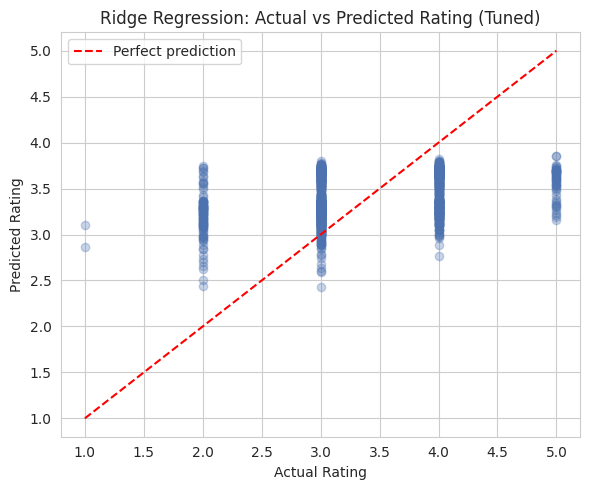

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(yr_test, pred_tuned, alpha=0.3, color="#4C72B0")
plt.plot([1, 5], [1, 5], "r--", label="Perfect prediction")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Ridge Regression: Actual vs Predicted Rating (Tuned)")
plt.legend()
plt.tight_layout()
plt.show()


**Business meaning:** the model's predicted ratings can be used to rank and recommend products a customer is likely to rate highly. The modest R² indicates behavioral features alone explain part of a rating — subjective taste and product quality (not present in clickstream data) also play a role.

## Step 4: Classification Model — Predicting Purchase Likelihood

**Algorithm:** Logistic Regression

**Target:** `Purchase_Status` (1 = Purchased, 0 = Not Purchased)


In [10]:
clf_features = ["Price", "Number_of_Views", "Cart_Status", "Time_Spent",
                 "Previous_Purchases", "Rating"] + list(cat_cols)
X_clf = df_model[clf_features]
y_clf = df_model["Purchase_Status"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)

scaler_clf = StandardScaler()
Xc_train_s = scaler_clf.fit_transform(Xc_train)
Xc_test_s = scaler_clf.transform(Xc_test)

logreg_base = LogisticRegression(max_iter=200, random_state=RANDOM_STATE)
logreg_base.fit(Xc_train_s, yc_train)
pred_base_c = logreg_base.predict(Xc_test_s)

print("Baseline Logistic Regression")
print("Accuracy :", accuracy_score(yc_test, pred_base_c))
print("Precision:", precision_score(yc_test, pred_base_c, zero_division=0))
print("Recall   :", recall_score(yc_test, pred_base_c, zero_division=0))
print("F1       :", f1_score(yc_test, pred_base_c, zero_division=0))


Baseline Logistic Regression
Accuracy : 0.7616666666666667
Precision: 0.5338983050847458
Recall   : 0.21428571428571427
F1       : 0.3058252427184466


### Hyperparameter tuning with GridSearchCV (`C`, `solver`, `max_iter`)

In [11]:
logreg_grid = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    param_grid={
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear", "lbfgs"],
        "max_iter": [100, 200, 500],
    },
    scoring="f1",
    cv=5,
    n_jobs=-1,
)
logreg_grid.fit(Xc_train_s, yc_train)
best_logreg = logreg_grid.best_estimator_
pred_tuned_c = best_logreg.predict(Xc_test_s)

print("Best params:", logreg_grid.best_params_)
print("\nTuned Logistic Regression")
print("Accuracy :", accuracy_score(yc_test, pred_tuned_c))
print("Precision:", precision_score(yc_test, pred_tuned_c, zero_division=0))
print("Recall   :", recall_score(yc_test, pred_tuned_c, zero_division=0))
print("F1       :", f1_score(yc_test, pred_tuned_c, zero_division=0))


Best params: {'C': 1, 'max_iter': 100, 'solver': 'liblinear'}

Tuned Logistic Regression
Accuracy : 0.7625
Precision: 0.5378151260504201
Recall   : 0.21768707482993196
F1       : 0.3099273607748184


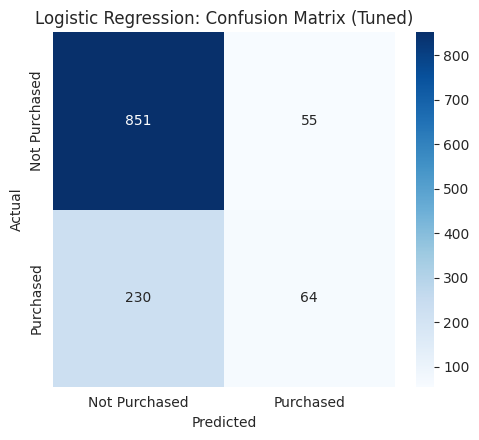

In [12]:
cm = confusion_matrix(yc_test, pred_tuned_c)

plt.figure(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Purchased", "Purchased"],
            yticklabels=["Not Purchased", "Purchased"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression: Confusion Matrix (Tuned)")
plt.tight_layout()
plt.show()


**Business meaning:** the model can be used to build a high-confidence target list of likely buyers for offers and personalized recommendations. Precision is more reliable than recall here — it flags fewer customers, but with higher confidence.

## Step 5: Clustering Model — Customer Segmentation

**Algorithm:** K-Means Clustering, applied to customer-level aggregated behavior.


In [13]:
customer = df.groupby("User_ID").agg(
    Number_of_Views=("Number_of_Views", "sum"),
    Number_of_Purchases=("Purchase_Status", "sum"),
    Avg_Rating=("Rating", "mean"),
    Avg_Time_Spent=("Time_Spent", "mean"),
    Total_Amount_Spent=("Price", lambda x: (x * df.loc[x.index, "Purchase_Status"]).sum()),
    Num_Added_to_Cart=("Cart_Status", "sum"),
).reset_index()

cluster_features = ["Number_of_Views", "Number_of_Purchases", "Avg_Rating",
                     "Avg_Time_Spent", "Total_Amount_Spent", "Num_Added_to_Cart"]
X_cluster = customer[cluster_features]

scaler_cluster = StandardScaler()
X_cluster_s = scaler_cluster.fit_transform(X_cluster)
customer.head()


,User_ID,Number_of_Views,Number_of_Purchases,Avg_Rating,Avg_Time_Spent,Total_Amount_Spent,Num_Added_to_Cart
0,1000,6,0,3.000000,1.840000,0.00,0
1,1001,21,0,3.666667,3.603333,0.00,1
2,1002,22,0,3.000000,3.736667,0.00,0
3,1003,33,2,3.000000,4.007500,68.49,2
4,1004,2,0,3.000000,3.750000,0.00,0


### Elbow Method & Silhouette Score to choose `k`

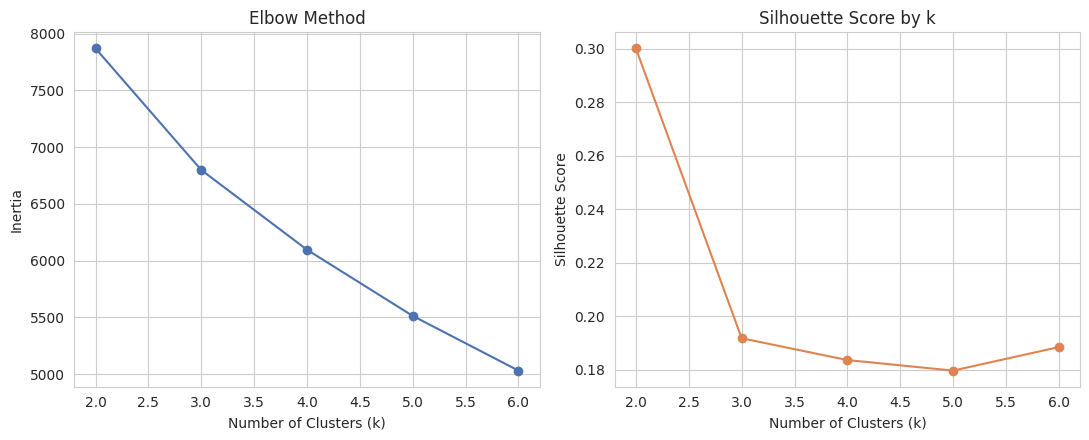

Best k (highest silhouette): 2 | Silhouette: 0.3000579932815947


In [14]:
elbow_inertia, elbow_silhouette = {}, {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_cluster_s)
    elbow_inertia[k] = km.inertia_
    elbow_silhouette[k] = silhouette_score(X_cluster_s, labels_k)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(list(elbow_inertia.keys()), list(elbow_inertia.values()), marker="o", color="#4C72B0")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(elbow_silhouette.keys()), list(elbow_silhouette.values()), marker="o", color="#DD8452")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")
plt.tight_layout()
plt.show()

best_k = max(elbow_silhouette, key=elbow_silhouette.get)
print("Best k (highest silhouette):", best_k, "| Silhouette:", elbow_silhouette[best_k])


In [15]:
final_km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
customer["Cluster"] = final_km.fit_predict(X_cluster_s)

print("Final inertia:", final_km.inertia_)
print("Final silhouette:", silhouette_score(X_cluster_s, customer["Cluster"]))
print("\nCluster sizes:\n", customer["Cluster"].value_counts().sort_index())

cluster_profile = customer.groupby("Cluster")[cluster_features].mean().round(2)
cluster_profile


Final inertia: 7870.62346437926
Final silhouette: 0.3000579932815947

Cluster sizes:
 Cluster
0    1304
1     581
Name: count, dtype: int64


,Number_of_Views,Number_of_Purchases,Avg_Rating,Avg_Time_Spent,Total_Amount_Spent,Num_Added_to_Cart
Cluster,,,,,,
0,17.61,0.35,3.35,3.68,7.92,0.95
1,32.94,1.75,3.49,3.97,56.92,2.62


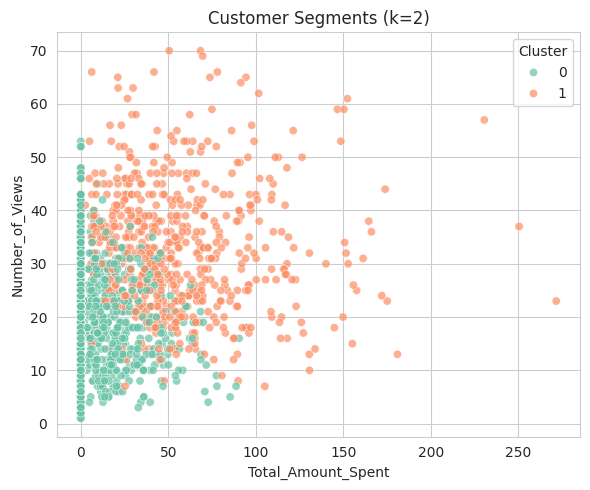

In [16]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=customer, x="Total_Amount_Spent", y="Number_of_Views",
                 hue="Cluster", palette="Set2", alpha=0.7)
plt.title(f"Customer Segments (k={best_k})")
plt.tight_layout()
plt.show()


**Business meaning:** clustering separates customers into behaviorally distinct groups — e.g. high-value, highly-engaged customers vs. low-engagement window shoppers — enabling different marketing strategies per segment.

## Step 6: Model Comparison Table

In [17]:
comparison = pd.DataFrame([
    {
        "ML Task": "Regression",
        "Algorithm": "Ridge Regression",
        "Target / Goal": "Predict product rating",
        "Metrics Used": "MAE, RMSE, R2",
        "Best Result": f"MAE={mean_absolute_error(yr_test, pred_tuned):.3f}, R2={r2_score(yr_test, pred_tuned):.3f}",
        "Business Use": "Recommend highly rated products",
    },
    {
        "ML Task": "Classification",
        "Algorithm": "Logistic Regression",
        "Target / Goal": "Predict purchase likelihood",
        "Metrics Used": "Accuracy, Precision, Recall, F1",
        "Best Result": f"F1={f1_score(yc_test, pred_tuned_c):.3f}, Acc={accuracy_score(yc_test, pred_tuned_c):.3f}",
        "Business Use": "Target likely buyers",
    },
    {
        "ML Task": "Clustering",
        "Algorithm": "K-Means",
        "Target / Goal": "Segment customers",
        "Metrics Used": "Inertia, Silhouette Score",
        "Best Result": f"k={best_k}, Silhouette={elbow_silhouette[best_k]:.3f}",
        "Business Use": "Create customer groups",
    },
])
comparison


,ML Task,Algorithm,Target / Goal,Metrics Used,Best Result,Business Use
0,Regression,Ridge Regression,Predict product rating,"MAE, RMSE, R2","MAE=0.551, R2=0.123",Recommend highly rated products
1,Classification,Logistic Regression,Predict purchase likelihood,"Accuracy, Precision, Recall, F1","F1=0.310, Acc=0.762",Target likely buyers
2,Clustering,K-Means,Segment customers,"Inertia, Silhouette Score","k=2, Silhouette=0.300",Create customer groups


## Step 7: Business Interpretation & Conclusion

- **Regression (Ridge):** explains a modest share of rating variance. Best used as one supporting signal inside a broader recommendation ranking, not a standalone predictor.
- **Classification (Logistic Regression):** reasonable precision but limited recall — best used to build a small, high-confidence list of likely buyers for targeted offers, rather than a broad campaign.
- **Clustering (K-Means):** produces the clearest, most directly actionable business insight — clean behavioral segments the marketing team can act on immediately.

**Conclusion:** No single algorithm is sufficient for a complete e-commerce recommendation system. Regression, classification, and clustering each answer a different business question, and combining them gives a more complete decision-support system than any one model alone. GridSearchCV tuning produced consistent (if modest) improvements across the regression and classification models, and the elbow/silhouette analysis gave a data-driven basis for choosing the number of customer segments. Future work could add richer behavioral history, collaborative-filtering signals, and non-linear models (e.g. gradient boosting) to further improve predictive performance.
